# Customer RFM Analysis
The objective of this notebook is to analyze customer purchasing behavior using the RFM (Recency, Frequency, Monetary) model. This analysis helps identify valuable customers and supports customer segmentation for targeted marketing strategies.

In [1]:
import pandas as pd
import numpy as np

In [ ]:
# Load Dataset
df = pd.read_csv("Retail_Feature_Engineered.csv")

In [ ]:
#Convert InvoiceDate
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

In [ ]:
#Create Reference Date
reference_date = df["InvoiceDate"].max() + pd.Timedelta(days=1)

print(reference_date)

2010-12-10 20:01:00


In [ ]:
#Calculate RFM
rfm = df.groupby("Customer ID").agg({
    "InvoiceDate": lambda x: (reference_date - x.max()).days,
    "Invoice": "nunique",
    "TotalAmount": "sum"
})

In [6]:
rfm.columns = ["Recency", "Frequency", "Monetary"]

In [7]:
rfm.head()

,Recency,Frequency,Monetary
Customer ID,,,
12346.0,165,11,372.86
12347.0,3,2,1323.32
12348.0,74,1,222.16
12349.0,43,3,2671.14
12351.0,11,1,300.93


In [ ]:
#RFM Statistics
rfm.describe()


,Recency,Frequency,Monetary
count,4312.000000,4312.000000,4312.000000
mean,91.171846,4.455705,2040.406712
std,96.860633,8.170213,8911.755977
min,1.000000,1.000000,2.950000
25%,18.000000,1.000000,307.187500
50%,53.000000,2.000000,701.615000
75%,136.000000,5.000000,1714.932500
max,374.000000,205.000000,349164.350000


In [9]:
#Recency Score
rfm["R_Score"] = pd.qcut(
    rfm["Recency"],
    5,
    labels=[5,4,3,2,1]
)

In [11]:
# Frequency Score
rfm["F_Score"] = pd.qcut(
    rfm["Frequency"].rank(method="first"),
    5,
    labels=[1,2,3,4,5]
)

In [12]:
#Monetary Score
rfm["M_Score"] = pd.qcut(
    rfm["Monetary"],
    5,
    labels=[1,2,3,4,5]
)

In [13]:
#Overall RFM Score
rfm["RFM_Score"] = (
    rfm["R_Score"].astype(str)
    + rfm["F_Score"].astype(str)
    + rfm["M_Score"].astype(str)
)

In [14]:
rfm.head()

,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score
Customer ID,,,,,,,
12346.0,165,11,372.86,2,5,2,252
12347.0,3,2,1323.32,5,2,4,524
12348.0,74,1,222.16,2,1,1,211
12349.0,43,3,2671.14,3,3,5,335
12351.0,11,1,300.93,5,1,2,512


In [15]:
#Customer Segmentation
def segment(row):

    if row["R_Score"] >= 4 and row["F_Score"] >= 4 and row["M_Score"] >= 4:
        return "Champions"

    elif row["R_Score"] >= 3 and row["F_Score"] >= 3:
        return "Loyal Customers"

    elif row["R_Score"] <= 2 and row["F_Score"] >= 3:
        return "At Risk"

    else:
        return "Others"

rfm["Segment"] = rfm.apply(segment, axis=1)

In [16]:
#Segment Count
rfm["Segment"].value_counts()

Segment
Others             1725
Loyal Customers     973
Champions           926
At Risk             688
Name: count, dtype: int64

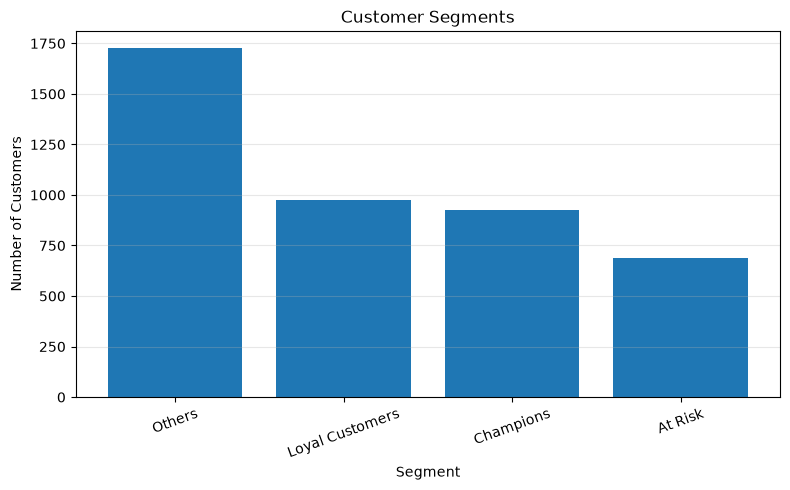

In [19]:
segment_counts = rfm["Segment"].value_counts()

import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.bar(
    segment_counts.index,
    segment_counts.values
)

plt.title("Customer Segments")
plt.xlabel("Segment")
plt.ylabel("Number of Customers")

plt.xticks(rotation=20)
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

## Business Insight

- Champions represent the most valuable customers.
- Loyal customers contribute consistent revenue.
- At Risk customers require retention strategies.
- Customer segmentation enables targeted marketing campaigns.

In [18]:
rfm.head(10)

,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score,Segment
Customer ID,,,,,,,,
12346.0,165,11,372.86,2,5,2,252,At Risk
12347.0,3,2,1323.32,5,2,4,524,Others
12348.0,74,1,222.16,2,1,1,211,Others
12349.0,43,3,2671.14,3,3,5,335,Loyal Customers
12351.0,11,1,300.93,5,1,2,512,Others
12352.0,11,2,343.80,5,2,2,522,Others
12353.0,44,1,317.76,3,1,2,312,Others
12355.0,203,1,488.21,1,1,2,112,Others
12356.0,16,3,3560.30,4,3,5,435,Loyal Customers


In [20]:
rfm.to_csv("Customer_RFM.csv", index=False)

## Conclusion

The RFM analysis classified customers based on Recency, Frequency, and Monetary value. This enables businesses to identify high-value customers, loyal customers, and customers at risk, supporting targeted marketing and retention strategies.